In [1]:
import os
import pickle
import gymnasium as gym
from keras import optimizers
import matplotlib.pyplot as plt
import ale_py
import numpy as np

# from mods
from model.agent import AgentPPO
from model.actor import Actor
from model.critic import Critic

print("Working dir:", os.getcwd())


Working dir: /Users/lukecrawford/Documents/GitHub/RL_project/ppo_v1


### Constants
- All available constants for hyperparameters etc

In [2]:

GAME = "ALE/Boxing-v5"
EPOCHSPERCYCLE = 3 # 3
# i.e how many sets of trajectories we sample under one 
CYCLES = 2000
EPISODESPERCYCLE = 5
SOLUTIONTHRESHOLD = 90 
COLLECTIONSIZE = 1787

# plotting stuff
PLOT = True
FIGURENAME = "Boxing_Fixed?"
LATEX = True
DIAGRAMWIDTH = 397.48499
BORDERTHICKNESS = 0.5
LINETHICKNESS = 0.6
STYLE = "latex_style.mplstyle"

# save stuff
SAVE = True
CHECKPOINTS = True
CHECKPOINTFREQ = COLLECTIONSIZE * EPISODESPERCYCLE * 10
actorPath = f"trainedModels/{GAME}{'/x/check/' if CHECKPOINTS else '/x/'}actor_model"
criticPath = f"trainedModels/{GAME}{'/x/check/' if CHECKPOINTS else '/x/'}critic_model"

# test parameters
TESTFREQ = COLLECTIONSIZE * EPISODESPERCYCLE * 10
TESTRUNMULTIPLE = 10

# load model
# replace x with the mean score to load different models
loadModel = True
loadPathActor = f'../Model_store/trainedModels_First_90/{GAME}/90/actor_model'
loadPathCritic = f'../Model_store/trainedModels_First_90/{GAME}/90/critic_model'

##
## PPO hyperparameters
# - Threshold to clip gradients by global norm
# - GAE threashold - has some bias variance tradeoff implications
# - NOT EPS GREEDY - this EPSCLIP the clipping threshold 
# - Return discount duh
TDLAMBDA = 0.90
DISCOUNT = 0.99
EPSCLIP = 0.2
GRADNORM = 0.5
ENTROPY = 0.005

# toggles
USEGAE = True
USEADV = False
USEENTROPY = True

# CNN hyperparameters
CONVOLUTIONS = False
ACTORCONVFILTERS = 32
ACTORDENSEUNITS = 256
CRITICCONVFILTERS = 32
CRITICDENSEUNITS = 512

# DONT use more than 100 for any of the attari games itll go OOM (probably)
BATCHSIZE = 64 # 64



### Loading Utils

In [3]:

def _ensure_optimizer_built(optimizer, variables):
    if hasattr(optimizer, "built") and not optimizer.built:
        optimizer.build(variables)


def save_training_state(base_actor_path, agent, actor_opt, critic_opt, game_seeds):
    _ensure_optimizer_built(actor_opt, agent.actor.cnn.trainable_variables)
    _ensure_optimizer_built(critic_opt, agent.critic.cnn.trainable_variables)

    training_data = {
        "rolling_mean_history": agent.rolling_mean_history,
        "rolling_mean_store": agent.rolling_mean_history,
        "reward_history": agent.reward_history,
        "step_history": agent.step_history,
        "total_steps": agent.total_steps,
        "total_updates": agent.total_updates,
        "agent_reward_history": agent.reward_history,
        "game_seeds": game_seeds,
        "actor_optimizer_weights": actor_opt.get_config(),
        "critic_optimizer_weights": critic_opt.get_config(),
        "actor_optimizer_iterations": int(actor_opt.iterations.numpy()),
        "critic_optimizer_iterations": int(critic_opt.iterations.numpy()),
    }

    file_path = base_actor_path.replace('actor_model', 'training_data.pkl')
    directory = os.path.dirname(file_path)
    if directory and not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)

    with open(file_path, "wb") as f:
        pickle.dump(training_data, f, protocol=pickle.HIGHEST_PROTOCOL)

### Game and Class initialisation

In [4]:

# start single env to get dimensions just to make like easier for changing games
env = gym.make(GAME, obs_type ='ram')
observation, info = env.reset()
dimensions = observation.shape
move_total = env.action_space.n   # type: ignore
env.close()

print(f"dims: {dimensions}, action_space: {move_total} ")

actor = Actor(
    dimensions=dimensions, 
    regression=False,
    total_moves=move_total,
    conv = CONVOLUTIONS,
    conv_filters=ACTORCONVFILTERS,
    dense_units=ACTORDENSEUNITS,
    eps_clip=EPSCLIP,
    gradnorm=GRADNORM,
    entropy= ENTROPY
)

critic = Critic(
    dimensions=dimensions, 
    regression=True,
    total_moves=move_total,
    conv = CONVOLUTIONS,
    conv_filters=CRITICCONVFILTERS,
    dense_units=CRITICDENSEUNITS,
    gradnorm=GRADNORM
) 

# agent constructor
agent = AgentPPO(
    d_size = EPISODESPERCYCLE,
    collection_size=COLLECTIONSIZE,
    actor= actor,
    critic= critic,
    discount = DISCOUNT, 
    epsilon = EPSCLIP,
    td_lambda = TDLAMBDA
)

# setup envs to be parallel 
envs = gym.make_vec(GAME, num_envs=EPISODESPERCYCLE, vectorization_mode="async",obs_type = "ram")


# lr = 0.00025
# these settings get ~72 (initial_learning_rate= 0.0000005 , decay_steps=250000, alpha=0.0025, warmup_steps=1000 , warmup_target=0.00025)
lr = optimizers.schedules.CosineDecay( initial_learning_rate= 0.0000005 , decay_steps=200000, alpha=0.05, warmup_steps=1000 , warmup_target=0.00025 )

act_opt = optimizers.AdamW(learning_rate = lr) # type: ignore
critic_opt = optimizers.AdamW(learning_rate = lr) # type: ignore

rng = np.random.default_rng()
# seeds stored in matrix, where [game generation seed , the rest -> epoch shuffle seeds]
game_seeds = rng.integers(low=0,high=4000000000, size=(CYCLES,EPOCHSPERCYCLE + 1), dtype=np.uint32)

# try loading models
if loadModel:
    # agent.loadModels(actor_path=loadPathActor, critic_path=loadPathCritic)
    
    filePath = loadPathActor.replace('actor_model', 'training_data.pkl')
    
    try:
        with open(filePath, "rb") as f:
            data = pickle.load(f)

        # rolling_hist = data.get("rolling_mean_history") or data.get("rolling_mean_store")
        # if rolling_hist is not None:
        #     agent.rolling_mean_history = rolling_hist

        # agent.reward_history = data.get("reward_history", agent.reward_history)
        # agent.step_history = data.get("step_history", agent.step_history)
        # agent.total_updates = data.get("total_updates", agent.total_updates)
        # agent.total_steps = data.get(
        #     "total_steps",
        #     agent.step_history[-1] if agent.step_history else agent.total_steps
        # )

        loaded_game_seeds = data.get("game_seeds")
        if loaded_game_seeds is not None and len(loaded_game_seeds) > 0:
            game_seeds = loaded_game_seeds

        # actor_opt_weights = data.get("actor_optimizer_weights")
        # if actor_opt_weights:
        #     _ensure_optimizer_built(act_opt, actor.cnn.trainable_variables)
        #     act_opt.set_weights(actor_opt_weights)

        # actor_opt_iterations = data.get("actor_optimizer_iterations")
        # if actor_opt_iterations is not None:
        #     act_opt.iterations.assign(actor_opt_iterations)

        # critic_opt_weights = data.get("critic_optimizer_weights")
        # if critic_opt_weights:
        #     _ensure_optimizer_built(critic_opt, critic.cnn.trainable_variables)
        #     critic_opt.set_weights(critic_opt_weights)

        # critic_opt_iterations = data.get("critic_optimizer_iterations")
        # if critic_opt_iterations is not None:
        #     critic_opt.iterations.assign(critic_opt_iterations)

        # if not agent.reward_history:
        #     agent.reward_history = [0]
        # if not agent.step_history:
        #     agent.step_history = [agent.total_steps]
        # if not agent.rolling_mean_history:
        #     agent.rolling_mean_history = [0]

        print(f"Loaded training state from {filePath}")
    except FileNotFoundError:
        print("No stored data found")

dims: (128,), action_space: 18 


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Loaded training state from ../Model_store/trainedModels_First_90/ALE/Boxing-v5/90/training_data.pkl


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


### Training
- Note: The mean comes from all terminal returns within a given sampling block
- The rolling mean is NOT test - that was unchanged from before, its simply a SMA of 20 over the sample means

In [5]:
##
## Main Training loop
##  
for cycle in range(CYCLES):
    # print(f"\n====================== Cycle {cycle} =========================\n")

    sample_mean, steps = agent.train_cycle(
        envs,
        game_seeds[cycle], 
        actor_opt=act_opt,
        critic_opt=critic_opt,
        epoch_num=EPOCHSPERCYCLE,
        batch_size=BATCHSIZE,
        use_gae = USEGAE,
        use_adv= USEADV,
        use_entropy=USEENTROPY,
    )

    total_updates = ((agent.total_steps/BATCHSIZE) * EPOCHSPERCYCLE)
    # print(f"\n ===>  , total steps this cycle: {steps} ")
    print(f" ===> Steps: {agent.total_steps} | Sample: {cycle} | GradUpdates: {total_updates:.0f} | lr = {critic_opt.learning_rate} | Mean Completed Score: {sample_mean} | Test Rolling Mean: {agent.rolling_mean_history[-1]:.2f}")


    if agent.rolling_mean_history[-1] > SOLUTIONTHRESHOLD:
        print(f"Solution Reached (Mean [-50:] = {agent.rolling_mean_history[-1]:.2f})")
        played_cycles = cycle
        break
        
    # if agent.total_steps % TESTFREQ == 0 and agent.total_steps > 0:
    #     agent.test(env=envs,test_num=TESTRUNMULTIPLE*COLLECTIONSIZE)

    
    if agent.total_steps % CHECKPOINTFREQ == 0 and agent.total_steps > 0 and CHECKPOINTS:
        checkpoint_actorPath = actorPath.replace('/check/', f'/{cycle}/')
        checkpoint_criticPath = criticPath.replace('/check/', f'/{cycle}/')
        agent.saveModels(actor_path=checkpoint_actorPath, critic_path=checkpoint_criticPath, checkpoint=True)
        save_training_state(checkpoint_actorPath, agent, act_opt, critic_opt, game_seeds)
        print(f"Checkpoint Models saved to {checkpoint_actorPath} and {checkpoint_criticPath} ")

    agent.clear_data_store()





 ===> Steps: 8935 | Sample: 0 | GradUpdates: 419 | lr = 2.1458001356222667e-05 | Mean Completed Score: 1.2 | Test Rolling Mean: 0.60
 ===> Steps: 17870 | Sample: 1 | GradUpdates: 838 | lr = 4.2416002543177456e-05 | Mean Completed Score: 0.4 | Test Rolling Mean: 0.53
 ===> Steps: 26805 | Sample: 2 | GradUpdates: 1256 | lr = 6.337399827316403e-05 | Mean Completed Score: -1.6 | Test Rolling Mean: 0.00
 ===> Steps: 35740 | Sample: 3 | GradUpdates: 1675 | lr = 8.433200127910823e-05 | Mean Completed Score: -1.6 | Test Rolling Mean: -0.32
 ===> Steps: 44675 | Sample: 4 | GradUpdates: 2094 | lr = 0.0001052899970090948 | Mean Completed Score: 1.0 | Test Rolling Mean: -0.10
 ===> Steps: 53610 | Sample: 5 | GradUpdates: 2513 | lr = 0.0001262480072909966 | Mean Completed Score: 2.8 | Test Rolling Mean: 0.31
 ===> Steps: 62545 | Sample: 6 | GradUpdates: 2932 | lr = 0.0001472060102969408 | Mean Completed Score: 4.0 | Test Rolling Mean: 0.77
 ===> Steps: 71480 | Sample: 7 | GradUpdates: 3351 | lr 

In [15]:
#Final Test

agent.test(env=envs,test_num=COLLECTIONSIZE * 100)

 =====> Test Episodes Mean Reward: 89.45309882747068 



In [9]:

# Save models + overwrite checkpoints
if SAVE:
    rolling = agent.rolling_mean_history[-1]
    if CHECKPOINTS:
        replace = '/x/check/'
    else:
        replace = '/x/'
    actorPath = actorPath.replace(replace, f'/{rolling:.0f}/')
    criticPath = criticPath.replace(replace, f'/{rolling:.0f}/')
    
    agent.saveModels(actor_path=actorPath, critic_path=criticPath, temp=f'{agent.rolling_mean_history[-1]:.0f}', checkpoint=False, saveCheckpoints=False)

    save_training_state(actorPath, agent, act_opt, critic_opt, game_seeds)

 Models saved to trainedModels/ALE/Boxing-v5/90/actor_model and trainedModels/ALE/Boxing-v5/90/critic_model 


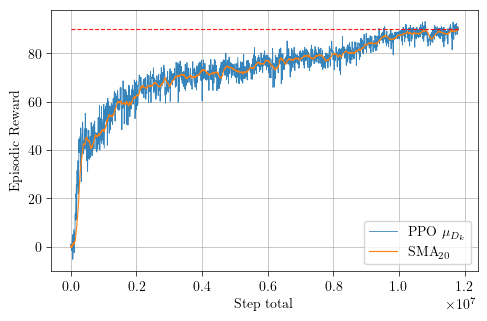

In [14]:

# plot the trajectory undiscounted return
if PLOT:
    plt.rcParams['grid.linewidth'] = BORDERTHICKNESS
    plt.rcParams['xtick.major.width'] = BORDERTHICKNESS
    plt.rcParams['ytick.major.width'] = BORDERTHICKNESS
    plt.rcParams['axes.linewidth'] = BORDERTHICKNESS
    plt.rcParams['lines.linewidth'] = LINETHICKNESS

    width = 20
    height = 10

    if LATEX: # https://duetosymmetry.com/code/latex-mpl-fig-tips/
        plt.rcParams.update({'text.usetex':True})
        plt.style.use(STYLE)
        pt = 1./72.27
        golden = (1 + 5 ** 0.5) / 2
        width = DIAGRAMWIDTH * pt
        height = width/golden

    step_his_np = (np.array(agent.step_history)/EPISODESPERCYCLE) * 4

    graph = plt.figure(figsize = (width,height))
    plt.plot(step_his_np, agent.reward_history, label = r"PPO $\mu_{D_k}$", alpha = 0.9)
    plt.plot(step_his_np, agent.rolling_mean_history, label = r"$\text{SMA}_{20}$", linewidth=0.8)
    plt.hlines(y=SOLUTIONTHRESHOLD, xmin=0, xmax= agent.total_steps/5 * 4, colors='r', linestyles='--', linewidth=0.8, alpha= 0.9)
    plt.xlabel(f"Step total")
    plt.ylabel("Episodic Reward")
    plt.legend(loc = 'lower right')
    plt.grid()
    plt.show()

    graph.savefig(FIGURENAME)